In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Set a clean style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
# Load the clean data
df = pd.read_csv("../data/processed/daily_demand_temperature.csv")
df["date"] = pd.to_datetime(df["date"])

In [4]:
print("Data loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully
Shape: (5208, 5)


,date,temp_max_f,temp_min_f,city,avg_demand_mw
0,2022-01-01,51.0,41.0,albany,15313.375000
1,2022-01-02,49.0,23.0,albany,15626.083333
2,2022-01-03,23.0,13.0,albany,18075.041667
3,2022-01-04,29.0,10.0,albany,19043.416667
4,2022-01-05,38.0,28.0,albany,18504.916667


In [5]:
# Calculate correlation
correlation = df["temp_max_f"].corr(df["avg_demand_mw"])
print(f"Correlation between Max Temperature and Demand: {correlation:.3f}")

Correlation between Max Temperature and Demand: 0.166


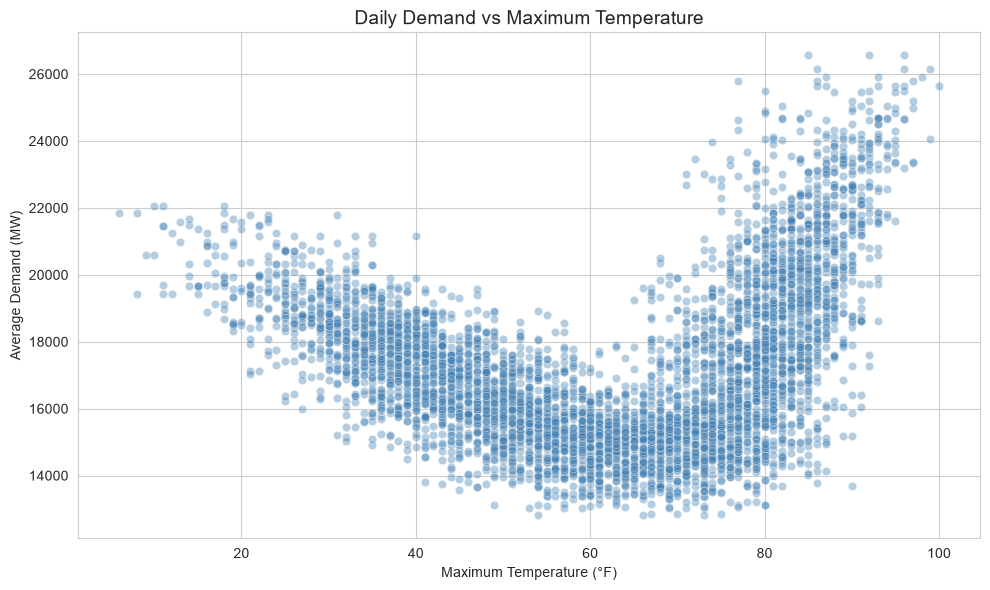

In [6]:
# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="temp_max_f", y="avg_demand_mw", alpha=0.4, color="steelblue")
plt.title("Daily Demand vs Maximum Temperature", fontsize=14)
plt.xlabel("Maximum Temperature (°F)")
plt.ylabel("Average Demand (MW)")
plt.tight_layout()
plt.show()

In [7]:
# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["date"].dt.month.apply(get_season)

In [8]:
# Average demand by season
season_summary = df.groupby("season")["avg_demand_mw"].agg(["mean", "count"]).round(1)
season_summary = season_summary.reindex(["Winter", "Spring", "Summer", "Fall"])
print(season_summary)

           mean  count
season                
Winter  18030.2   1260
Spring  15248.6   1380
Summer  19523.1   1380
Fall    16004.6   1188


C:\Users\khushi\AppData\Local\Temp\ipykernel_16388\1636116615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="season", y="avg_demand_mw",


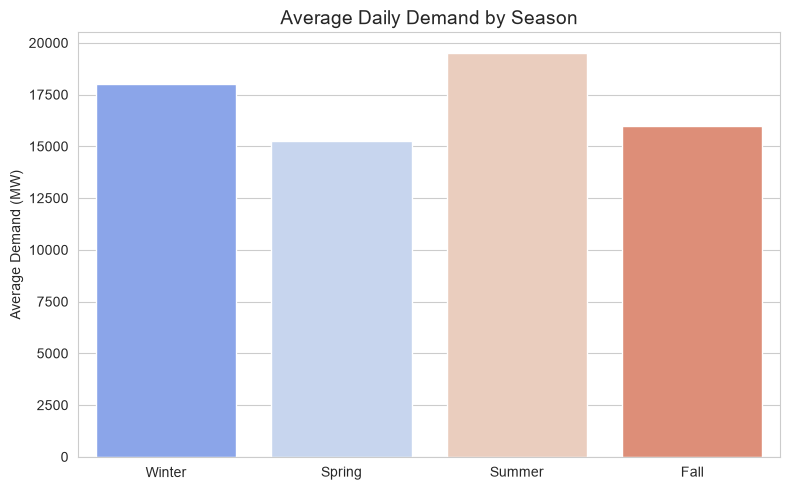

In [9]:
# Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="season", y="avg_demand_mw", 
            order=["Winter", "Spring", "Summer", "Fall"],
            palette="coolwarm", errorbar=None)
plt.title("Average Daily Demand by Season", fontsize=14)
plt.ylabel("Average Demand (MW)")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [11]:
# Create temperature group
df["temp_group"] = df["temp_max_f"].apply(lambda x: "Hot (>80°F)" if x > 80 else "Not Hot (≤80°F)")

# Compare average demand
threshold_summary = df.groupby("temp_group")["avg_demand_mw"].agg(["mean", "count"]).round(1)
print(threshold_summary)

                    mean  count
temp_group                     
Hot (>80°F)      19858.3   1027
Not Hot (≤80°F)  16580.3   4181


C:\Users\khushi\AppData\Local\Temp\ipykernel_16388\1921274912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="temp_group", y="avg_demand_mw", palette="Set2")


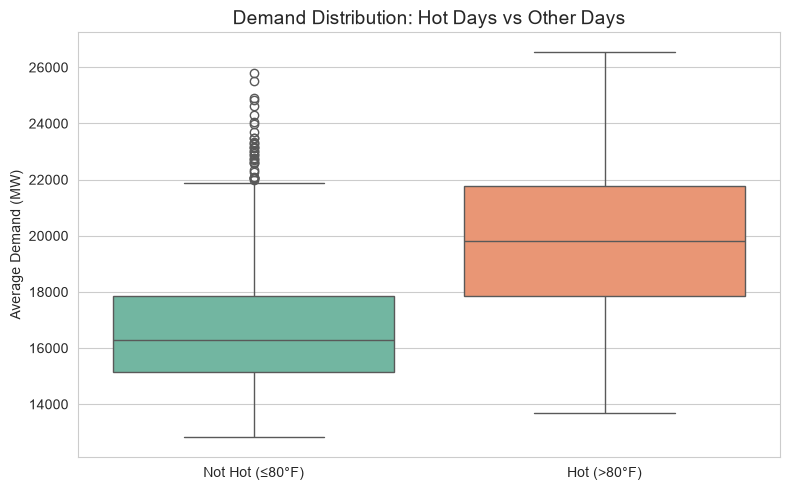

In [12]:
# Box plot for clearer comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="temp_group", y="avg_demand_mw", palette="Set2")
plt.title("Demand Distribution: Hot Days vs Other Days", fontsize=14)
plt.ylabel("Average Demand (MW)")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [13]:
# Create temperature bins
bins = [0, 30, 40, 50, 60, 70, 80, 90, 110]
labels = ["<30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90+"]
df["temp_bin"] = pd.cut(df["temp_max_f"], bins=bins, labels=labels)

# Average demand per bin
bin_summary = df.groupby("temp_bin", observed=True)["avg_demand_mw"].mean().round(1)
print(bin_summary)

temp_bin
<30      19279.4
30-40    17750.5
40-50    16551.5
50-60    15473.4
60-70    15186.7
70-80    16810.3
80-90    19427.0
90+      22860.1
Name: avg_demand_mw, dtype: float64


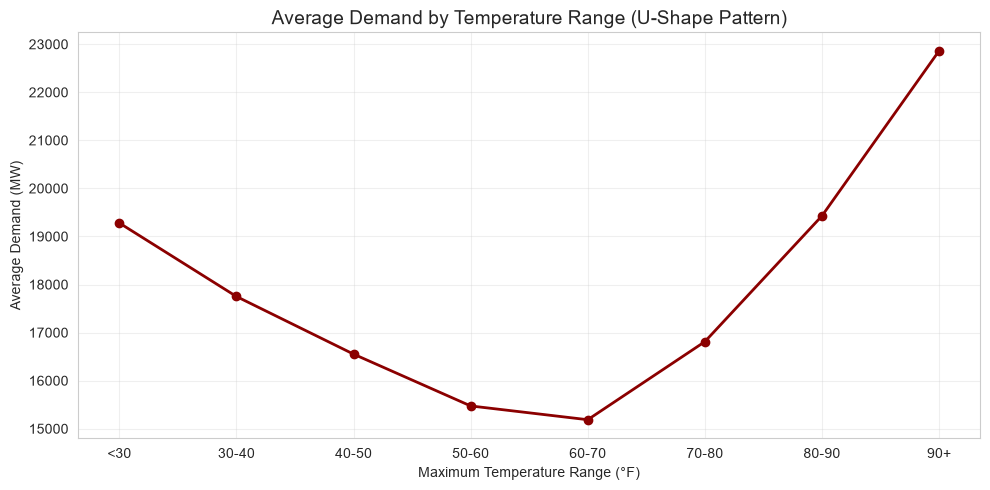

In [14]:
# Line plot to show the U-shape
plt.figure(figsize=(10, 5))
bin_summary.plot(kind="line", marker="o", color="darkred", linewidth=2)
plt.title("Average Demand by Temperature Range (U-Shape Pattern)", fontsize=14)
plt.ylabel("Average Demand (MW)")
plt.xlabel("Maximum Temperature Range (°F)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()